In [37]:
from pandas import read_csv,DataFrame
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split,RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.neighbors import KNeighborsRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.preprocessing import OneHotEncoder,StandardScaler
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score,root_mean_squared_error

import joblib

In [2]:
df = read_csv("data/tip.csv")

In [3]:
df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [4]:
df.tail()

,total_bill,tip,sex,smoker,day,time,size
239,29.03,5.92,Male,No,Sat,Dinner,3
240,27.18,2.00,Female,Yes,Sat,Dinner,2
241,22.67,2.00,Male,Yes,Sat,Dinner,2
242,17.82,1.75,Male,No,Sat,Dinner,2
243,18.78,3.00,Female,No,Thur,Dinner,2


In [5]:
df.shape

(244, 7)

In [6]:
df.isna().sum()

total_bill    0
tip           0
sex           0
smoker        0
day           0
time          0
size          0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(1)

In [8]:
df.drop_duplicates(inplace=True)

In [9]:
df.info()

<class 'pandas.DataFrame'>
Index: 243 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   total_bill  243 non-null    float64
 1   tip         243 non-null    float64
 2   sex         243 non-null    str    
 3   smoker      243 non-null    str    
 4   day         243 non-null    str    
 5   time        243 non-null    str    
 6   size        243 non-null    int64  
dtypes: float64(2), int64(1), str(4)
memory usage: 15.2 KB


In [10]:
df.describe()

,total_bill,tip,size
count,243.000000,243.000000,243.000000
mean,19.813868,3.002387,2.572016
std,8.910071,1.385002,0.952356
min,3.070000,1.000000,1.000000
25%,13.380000,2.000000,2.000000
50%,17.810000,2.920000,2.000000
75%,24.175000,3.575000,3.000000
max,50.810000,10.000000,6.000000


In [11]:
df.describe(include="str")

,sex,smoker,day,time
count,243,243,243,243
unique,2,2,4,2
top,Male,No,Sat,Dinner
freq,157,151,87,176


------------------------------------------------------------  Countplot For Sex column  ------------------------------------------------------------
sex
Male      157
Female     86
Name: count, dtype: int64
-------------------------------------------------------------------------------------
sex
Male      64.609053
Female    35.390947
Name: proportion, dtype: float64


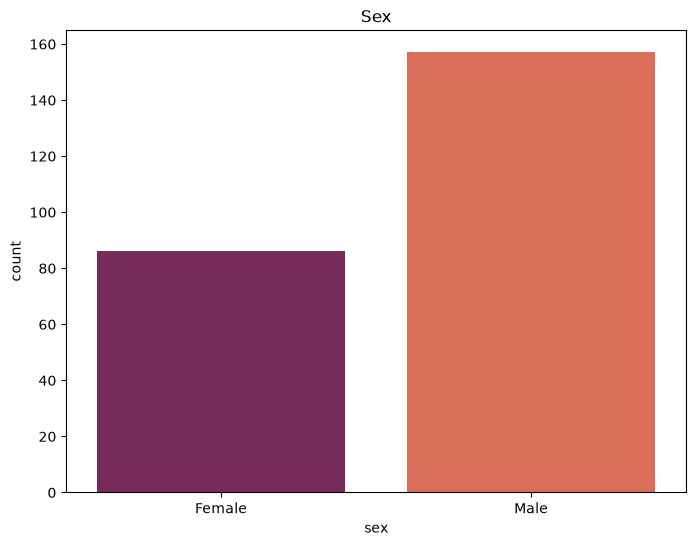

------------------------------------------------------------  Countplot For Smoker column  ------------------------------------------------------------
smoker
No     151
Yes     92
Name: count, dtype: int64
-------------------------------------------------------------------------------------
smoker
No     62.139918
Yes    37.860082
Name: proportion, dtype: float64


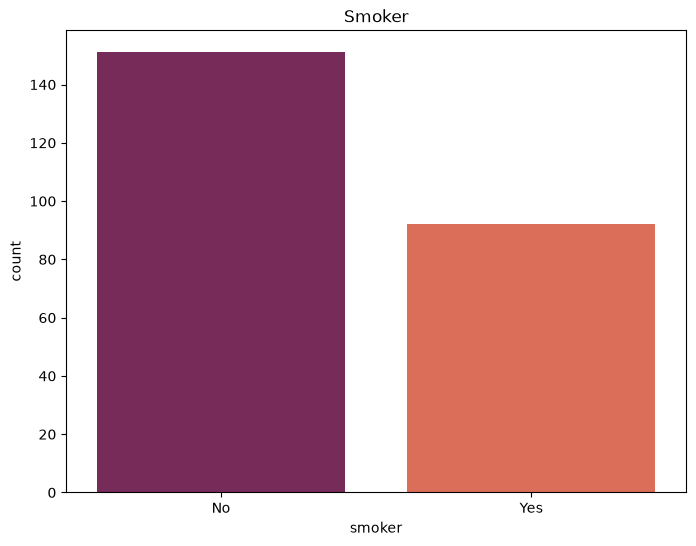

------------------------------------------------------------  Countplot For Day column  ------------------------------------------------------------
day
Sat     87
Sun     76
Thur    61
Fri     19
Name: count, dtype: int64
-------------------------------------------------------------------------------------
day
Sat     35.802469
Sun     31.275720
Thur    25.102881
Fri      7.818930
Name: proportion, dtype: float64


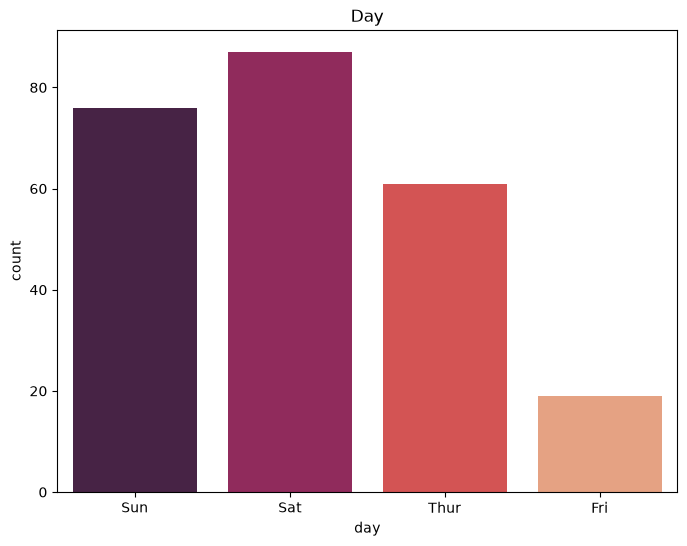

------------------------------------------------------------  Countplot For Time column  ------------------------------------------------------------
time
Dinner    176
Lunch      67
Name: count, dtype: int64
-------------------------------------------------------------------------------------
time
Dinner    72.427984
Lunch     27.572016
Name: proportion, dtype: float64


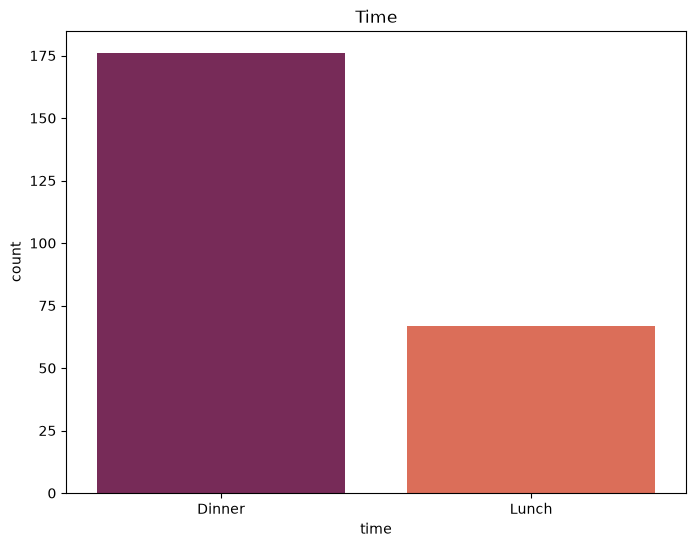

In [13]:
cols_count = {
    "sex":"Sex",
    "smoker":"Smoker",
    "day":"Day",
    "time":"Time"
}

for col,ti in cols_count.items():
    print("-"*60,f" Countplot For {ti} column ","-"*60)
    print(df[col].value_counts())
    print("-"*85)
    print(df[col].value_counts(normalize=True)*100)

    plt.figure(figsize=(8,6))
    sns.countplot(df,x=col,hue=col,legend=False,palette="rocket")
    plt.title(ti)
    plt.savefig(f"images/Countplots/{ti}.png",
        dpi=300,
        bbox_inches="tight")
    plt.show()

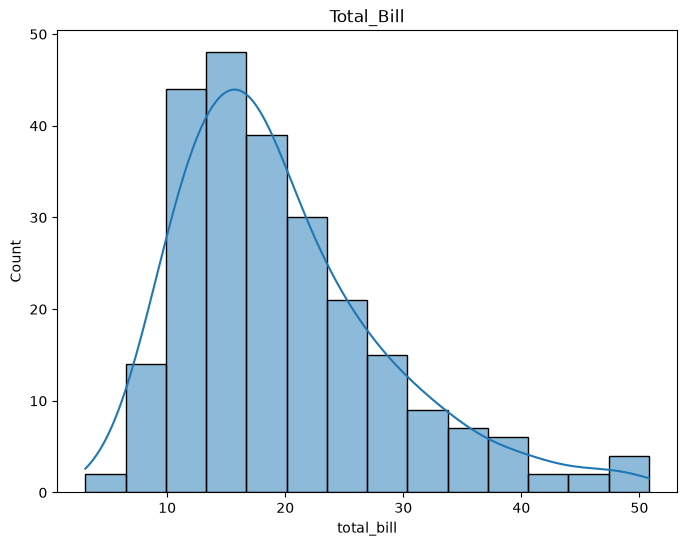

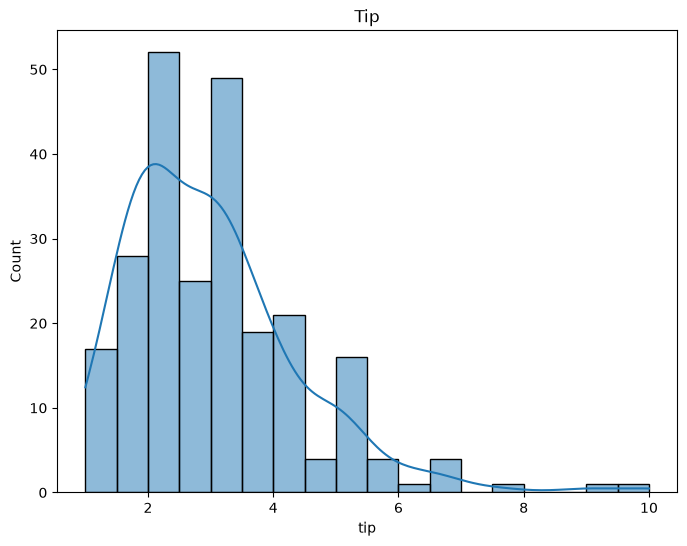

In [14]:
cols_hist= {
    "total_bill":"Total_Bill",
    "tip":"Tip"
}

for col,ti in cols_hist.items():
    plt.figure(figsize=(8,6))
    sns.histplot(df,x=col,kde=True)
    plt.title(ti)
    plt.savefig(f"images/Histplots/{ti}.png",
        dpi=300,
        bbox_inches="tight")
    plt.show()

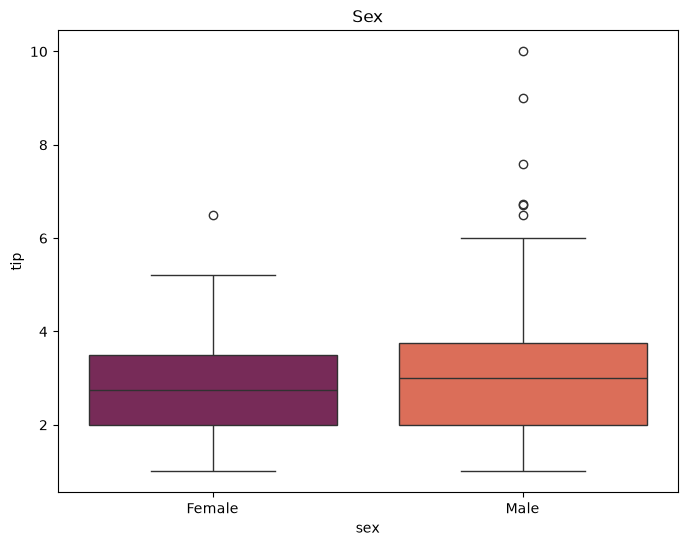

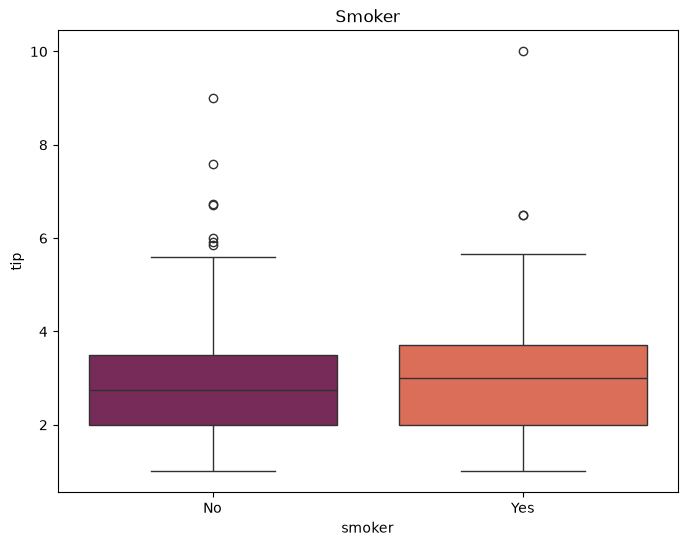

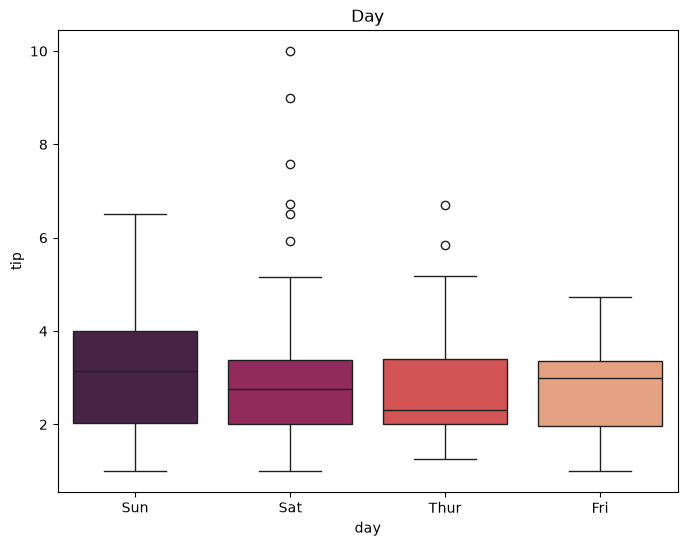

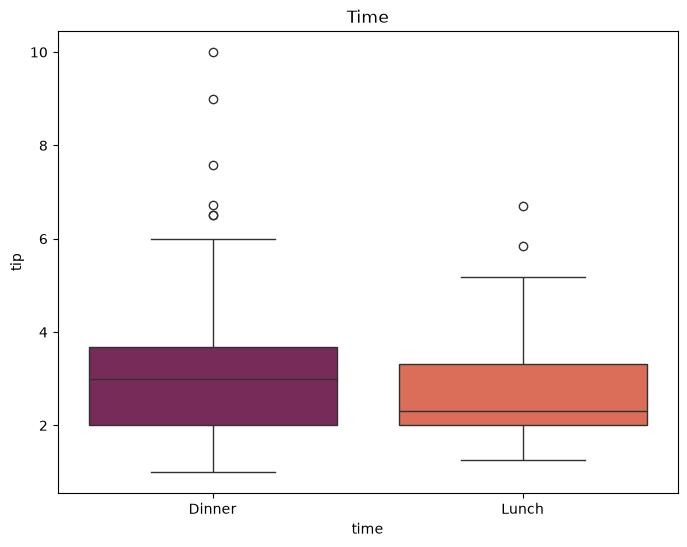

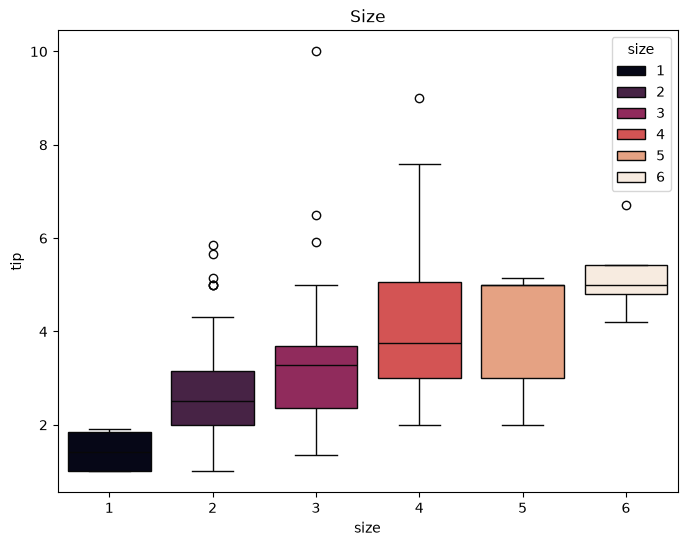

In [15]:
cols_box = {
    "sex":"Sex",
    "smoker":"Smoker",
    "day":"Day",
    "time":"Time",
    "size":"Size"
}

for col ,ti in cols_box.items():
    plt.figure(figsize=(8,6))
    sns.boxplot(df,x=col,y="tip",hue=col,palette="rocket")
    plt.title(ti)
    plt.savefig(f"images/Boxplots/{ti}.png",
        dpi=300,
        bbox_inches="tight")
    plt.show()

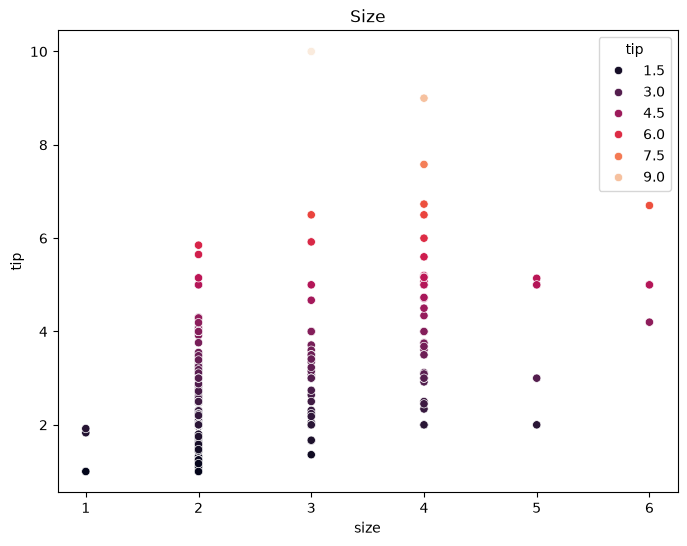

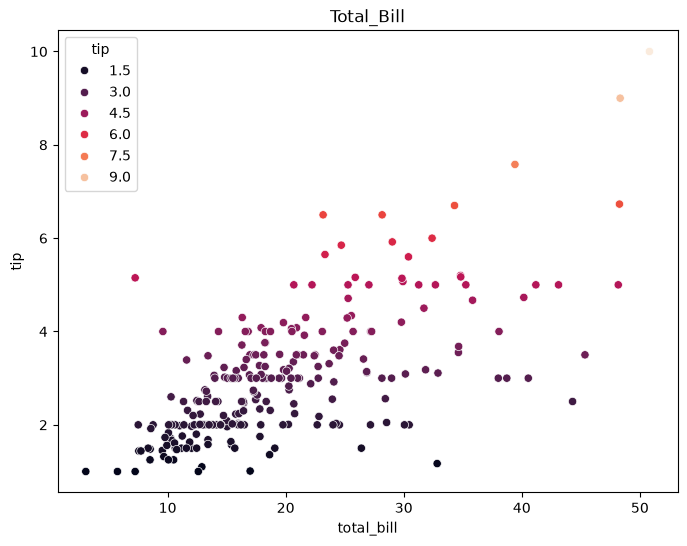

In [16]:
cols_scat = {
    "size":"Size",
    "total_bill":"Total_Bill"
}

for col,ti in cols_scat.items():
    plt.figure(figsize=(8,6))
    sns.scatterplot(df,x=col,y="tip",hue="tip",palette="rocket")
    plt.title(ti)
    plt.savefig(f"images/Scatterplots/{ti}.png",
        dpi=300,
        bbox_inches="tight")
    plt.show()

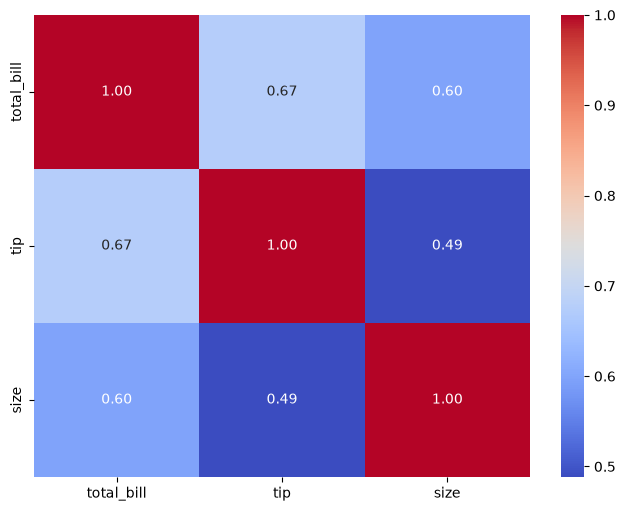

In [17]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True),annot=True,fmt=".2f",cmap="coolwarm")
plt.savefig(f"images/Heatmap/heatmap.png",
        dpi=300,
        bbox_inches="tight")
plt.show()

In [18]:
df["sex"]= df["sex"].replace({
    "Male":0,
    "Female":1
})

df["smoker"] = df["smoker"].replace({
    "Yes":0,
    "No":1
})

df["day"] = df["day"].replace({
    "Sun":0,
    "Sat":1,
    "Thur":2,
    "Fri":3
})

df["time"] = df["time"].replace({
    "Dinner":0,
    "Lunch":1
})

In [19]:
X = df.drop("tip",axis=1)
y = df["tip"]

x_train,x_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [20]:
numeric_col = ["total_bill","size"]

cat_col = ["sex","smoker","day","time"]

In [21]:
knn_preprocessor = ColumnTransformer([
    ("num",StandardScaler(),numeric_col),
    ("cat",OneHotEncoder(handle_unknown='ignore'),cat_col)
])

tree_preprocessor = ColumnTransformer([
    ("num","passthrough",numeric_col),
    ("cat",OneHotEncoder(handle_unknown="ignore"),cat_col)
])

KNeighbors

In [22]:
pipe_knn = Pipeline([
    ("preprocessor",knn_preprocessor),
    ("model",KNeighborsRegressor())
])

param_knn = {
    "model__n_neighbors": [3, 5, 7, 9, 11, 15],
    "model__weights": ["uniform", "distance"],
    "model__metric": ["euclidean", "manhattan"]
}

In [23]:
grid_knn = RandomizedSearchCV(pipe_knn,param_knn,n_iter=20,cv=5,scoring="neg_mean_absolute_error",verbose=1,n_jobs=-1,error_score="raise")

In [24]:
grid_knn.fit(x_train,y_train)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...Regressor())])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'model__metric': ['euclidean', 'manhattan'], 'model__n_neighbors': [3, 5, ...], 'model__weights': ['uniform', 'distance']}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",20
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'neg_mean_absolute_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: int, default = 0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"error_score error_score: 'raise' or numeric, default=np.nanValue to assign to the score if an error occurs in estimator fitting.If set to 'raise', the error is raised. If a numeric value is given,FitFailedWarning is raised. This parameter does not affect the refitstep, which will always raise the error.",'raise'
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whi

In [25]:
print("-"*45," KNeighbors ","-"*45)
print("Best Params : ",grid_knn.best_params_)
print("Best Score : ",grid_knn.best_score_)

---------------------------------------------  KNeighbors  ---------------------------------------------
Best Params :  {'model__weights': 'distance', 'model__n_neighbors': 15, 'model__metric': 'euclidean'}
Best Score :  -0.8167571813397723


XGBoost

In [26]:
pipe_xg = Pipeline([
    ("preprocessor",tree_preprocessor),
    ("model",XGBRegressor(random_state=42,eval_metric="logloss"))
])

param_xg = {
    "model__n_estimators": [50, 100, 200, 300],
    "model__max_depth": [2, 3, 4, 5],
    "model__learning_rate": [0.01, 0.05, 0.1],
    "model__subsample": [0.8, 1.0],
    "model__colsample_bytree": [0.8, 1.0]
}

In [27]:
grid_xg = RandomizedSearchCV(pipe_xg,param_xg,n_iter=20,cv=5,scoring="neg_mean_absolute_error",verbose=1,n_jobs=-1,error_score="raise")

In [28]:
grid_xg.fit(x_train,y_train)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...=None, ...))])"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'model__colsample_bytree': [0.8, 1.0], 'model__learning_rate': [0.01, 0.05, ...], 'model__max_depth': [2, 3, ...], 'model__n_estimators': [50, 100, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",20
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'neg_mean_absolute_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: int, default = 0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"error_score error_score: 'raise' or numeric, default=np.nanValue to assign to the score if an error occurs in estimator fitting.If set to 'raise', the error is raised. If a numeric value is given,FitFailedWarning is raised. This parameter does not affect the refitstep, which will always raise the error.",'raise'
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, 

In [29]:
print("-"*45," XGBoots ","-"*45)
print("Best Params : ",grid_xg.best_params_)
print("Best Score : ",grid_xg.best_score_)

---------------------------------------------  XGBoots  ---------------------------------------------
Best Params :  {'model__subsample': 1.0, 'model__n_estimators': 100, 'model__max_depth': 2, 'model__learning_rate': 0.05, 'model__colsample_bytree': 1.0}
Best Score :  -0.7809615184729881


LightGBM

In [30]:
pipe_LGBM = Pipeline([
    ("preprocessor",tree_preprocessor),
    ("model",LGBMRegressor(random_state=42,verbosity=-1,n_jobs=1))
])

param_LGBM = {
    "model__n_estimators": [50, 100, 200, 300],
    "model__max_depth": [-1, 3, 5, 7],
    "model__learning_rate": [0.01, 0.05, 0.1],
    "model__num_leaves": [15, 31, 50],
    "model__subsample": [0.8, 1.0]
}

In [31]:
grid_LGBM = RandomizedSearchCV(pipe_LGBM,param_LGBM,n_iter=20,cv=5,scoring="neg_mean_absolute_error",verbose=1,n_jobs=1,error_score="raise")

In [32]:
grid_LGBM.fit(x_train,y_train)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...rbosity=-1))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'model__learning_rate': [0.01, 0.05, ...], 'model__max_depth': [-1, 3, ...], 'model__n_estimators': [50, 100, ...], 'model__num_leaves': [15, 31, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",20
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'neg_mean_absolute_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: int, default = 0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"error_score error_score: 'raise' or numeric, default=np.nanValue to assign to the score if an error occurs in estimator fitting.If set to 'raise', the error is raised. If a numeric value is given,FitFailedWarning is raised. This parameter does not affect the refitstep, which will always raise the error.",'raise'
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``ref

In [33]:
print("-"*45," LightGBM ","-"*45)
print("Best Params : ",grid_LGBM.best_params_)
print("Best Score : ",grid_LGBM.best_score_)

---------------------------------------------  LightGBM  ---------------------------------------------
Best Params :  {'model__subsample': 1.0, 'model__num_leaves': 31, 'model__n_estimators': 100, 'model__max_depth': 3, 'model__learning_rate': 0.05}
Best Score :  -0.7940297022453937


In [34]:
Models = {
    "KNeighbors":grid_knn.best_estimator_,
    "XGBoots":grid_xg.best_estimator_,
    "LightGBM":grid_LGBM.best_estimator_
}

results = []

for name, model in Models.items():

    y_pred = model.predict(x_test)

    results.append({
        "Model": name,
        "MAE":mean_absolute_error(y_test,y_pred),
        "MSE":mean_squared_error(y_test,y_pred),
        "R2":r2_score(y_test,y_pred),
        "RMSE":root_mean_squared_error(y_test,y_pred)
    })

In [35]:
res_df = DataFrame(results,index=['','',''])
res_df

,Model,MAE,MSE,R2,RMSE
,KNeighbors,0.801290,1.394831,0.427521,1.181030
,XGBoots,0.755477,1.045346,0.570960,1.022421
,LightGBM,0.792142,1.476054,0.394185,1.214930


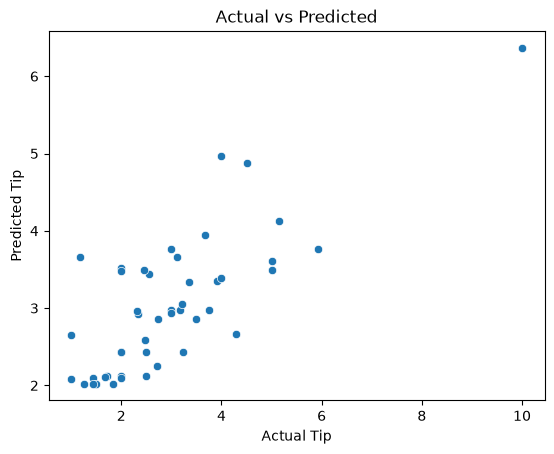

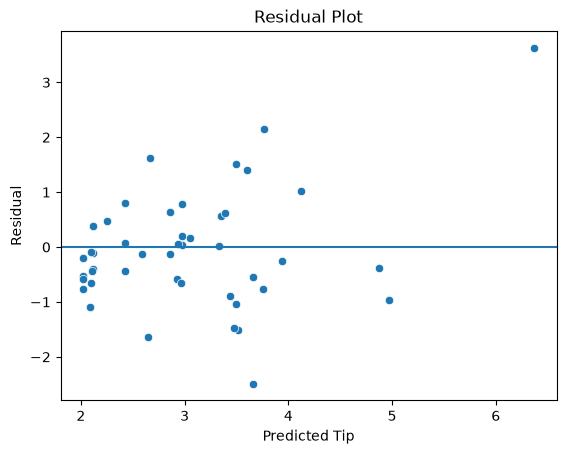

In [36]:
y_pred = grid_xg.predict(x_test)

sns.scatterplot(x=y_test, y=y_pred,)

plt.xlabel("Actual Tip")
plt.ylabel("Predicted Tip")
plt.title("Actual vs Predicted")
plt.savefig(f"images/Modelplots/Actual_vs_predict.png",
        dpi=300,
        bbox_inches="tight")
plt.show()


residuals = y_test - y_pred

sns.scatterplot(x=y_pred, y=residuals)

plt.axhline(0)
plt.xlabel("Predicted Tip")
plt.ylabel("Residual")
plt.title("Residual Plot")
plt.savefig(f"images/Modelplots/Residuals.png",
        dpi=300,
        bbox_inches="tight")
plt.show()

In [38]:
joblib.dump(grid_knn.best_estimator_,"models/KNeighbors_Model.joblib")
joblib.dump(grid_xg.best_estimator_,"models/XGBoost_Model.joblib")
joblib.dump(grid_LGBM.best_estimator_,"models/LightGBM_Model.joblib")
print("Models Saved")

Models Saved
